In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from matplotlib.colors import ListedColormap
from ucimlrepo import fetch_ucirepo

sklearn.set_config(transform_output="pandas")

# Part 1

In [2]:
# fetch dataset
ionosphere = fetch_ucirepo(id=52)

# data (as pandas dataframes)
X: pd.DataFrame = ionosphere.data.features
y: pd.DataFrame = ionosphere.data.targets

# metadata
# print(ionosphere.metadata)

# variable information
# display(ionosphere.variables)

In [3]:
print("Shape of X:", X.shape)
display(X.describe())

print("Shape of y:", y.shape)
display(y.describe())

print("Class distribution in y:")
display(y.value_counts(normalize=True))

Shape of X: (351, 34)


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute25,Attribute26,Attribute27,Attribute28,Attribute29,Attribute30,Attribute31,Attribute32,Attribute33,Attribute34
count,351.000000,351.0,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,...,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000
mean,0.891738,0.0,0.641342,0.044372,0.601068,0.115889,0.550095,0.119360,0.511848,0.181345,...,0.396135,-0.071187,0.541641,-0.069538,0.378445,-0.027907,0.352514,-0.003794,0.349364,0.014480
std,0.311155,0.0,0.497708,0.441435,0.519862,0.460810,0.492654,0.520750,0.507066,0.483851,...,0.578451,0.508495,0.516205,0.550025,0.575886,0.507974,0.571483,0.513574,0.522663,0.468337
min,0.000000,0.0,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1.000000,0.0,0.472135,-0.064735,0.412660,-0.024795,0.211310,-0.054840,0.087110,-0.048075,...,0.000000,-0.332390,0.286435,-0.443165,0.000000,-0.236885,0.000000,-0.242595,0.000000,-0.165350
50%,1.000000,0.0,0.871110,0.016310,0.809200,0.022800,0.728730,0.014710,0.684210,0.018290,...,0.553890,-0.015050,0.708240,-0.017690,0.496640,0.000000,0.442770,0.000000,0.409560,0.000000
75%,1.000000,0.0,1.000000,0.194185,1.000000,0.334655,0.969240,0.445675,0.953240,0.534195,...,0.905240,0.156765,0.999945,0.153535,0.883465,0.154075,0.857620,0.200120,0.813765,0.171660
max,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Shape of y: (351, 1)


,Class
count,351
unique,2
top,g
freq,225


Class distribution in y:


Class
g        0.641026
b        0.358974
Name: proportion, dtype: float64

In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(random_state=42),
    "MLP": MLPClassifier(max_iter=1000, random_state=42),
}

In [5]:
from sklearn.model_selection import cross_validate

for name, model in models.items():
    print(f"Evaluating {name}...")

    cv_results = cross_validate(
        model, X.values, y.values.ravel(), cv=kf, return_train_score=True
    )

    avg_train_acc = np.mean(cv_results["train_score"])
    avg_test_acc = np.mean(cv_results["test_score"])

    print(f"  Average Train Accuracy: {avg_train_acc:.4f}")
    print(f"  Average Test Accuracy:  {avg_test_acc:.4f}")

Evaluating Decision Tree...
  Average Train Accuracy: 1.0000
  Average Test Accuracy:  0.8974
Evaluating Random Forest...
  Average Train Accuracy: 1.0000
  Average Test Accuracy:  0.9344
Evaluating Logistic Regression...
  Average Train Accuracy: 0.9117
  Average Test Accuracy:  0.8773
Evaluating SVM...
  Average Train Accuracy: 0.9630
  Average Test Accuracy:  0.9373
Evaluating MLP...
  Average Train Accuracy: 0.9972
  Average Test Accuracy:  0.9115


# Part 2

In [6]:
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    markers = ("o", "s", "^", "v", "<")
    colors = ("blue", "red", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colors[: len(np.unique(y))])

    x1_min, x1_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    x2_min, x2_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution)
    )

    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)

    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl].iloc[:, 0],
            y=X[y == cl].iloc[:, 1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=f"Class {cl}",
            edgecolor="black",
        )

In [7]:
space_df = pd.read_csv("space.csv")
display(space_df.head())

X_space = space_df[["x", "y"]]
y_space = space_df["label"]

,x,y,label
0,-0.854800,-0.010376,0.0
1,0.355699,-0.519722,0.0
2,0.095440,0.777868,0.0
3,0.931966,-0.055718,0.0
4,-0.105374,0.987070,0.0


Training Decision Tree on the entire dataset...


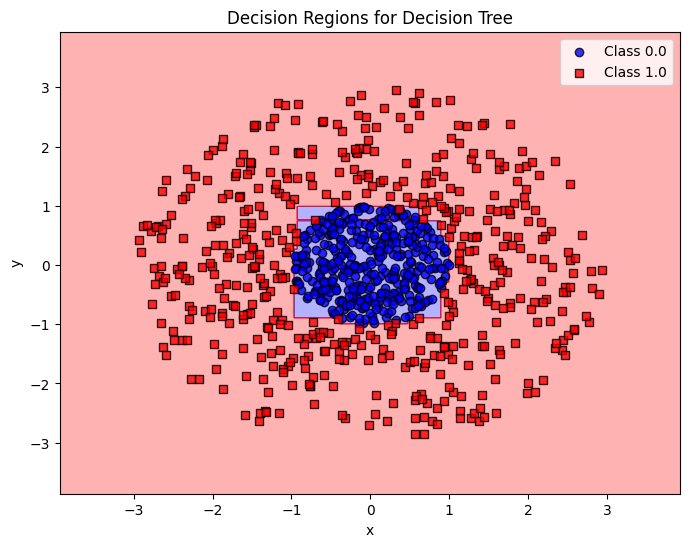

Training Random Forest on the entire dataset...


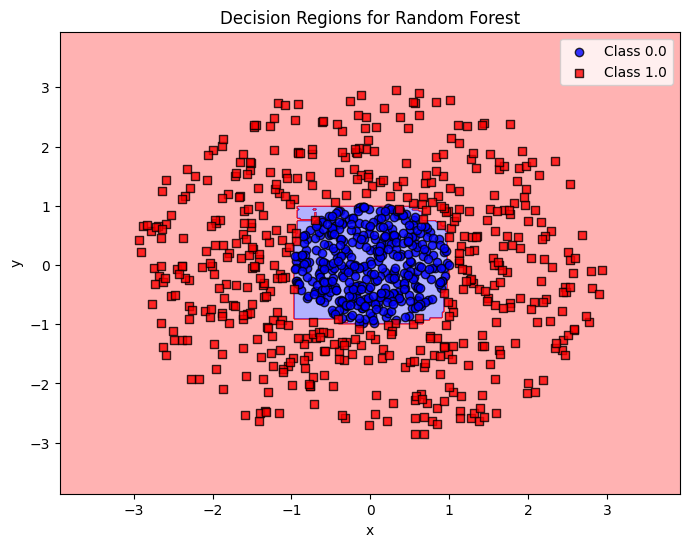

Training Logistic Regression on the entire dataset...


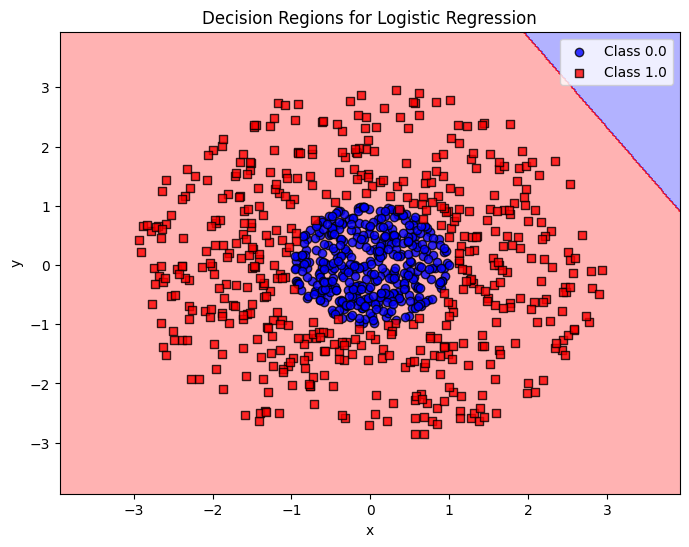

Training SVM on the entire dataset...


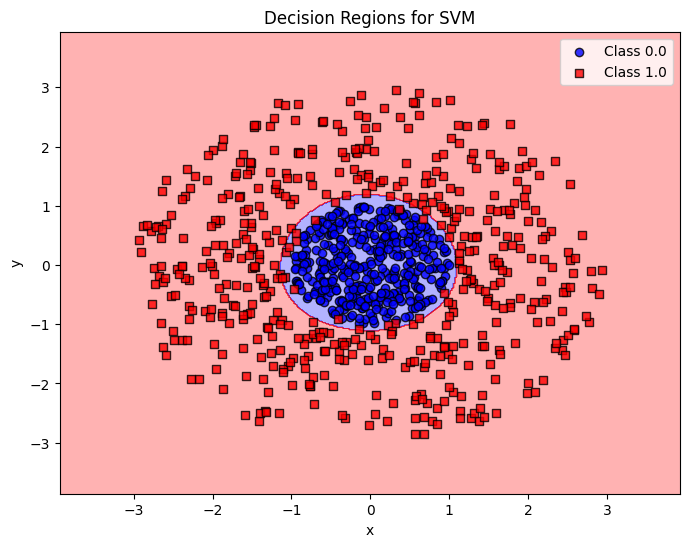

Training MLP on the entire dataset...


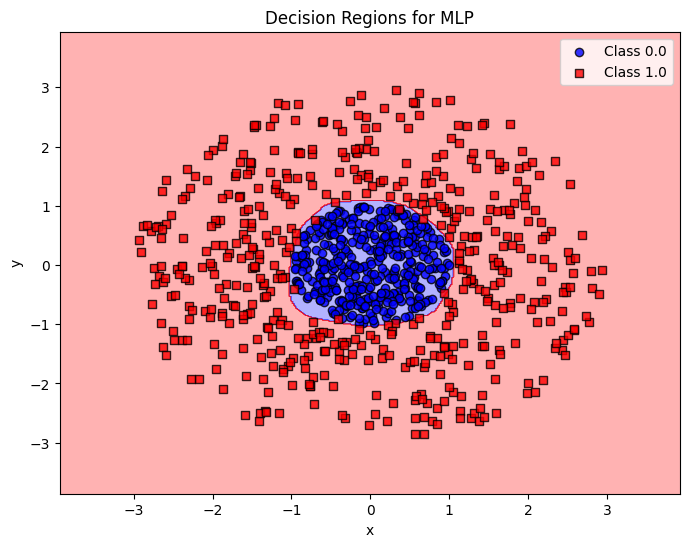

In [8]:
for name, model in models.items():
    print(f"Training {name} on the entire dataset...")
    model.fit(X_space.values, y_space.values.ravel())
    plt.figure(figsize=(8, 6))
    plot_decision_regions(X_space, y_space, classifier=model)
    plt.title(f"Decision Regions for {name}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

# Part 3

[K-means visualization website](https://alekseynp.com/viz/k-means.html)

![kmeans1.png](kmeans1.png)
![kmeans2.png](kmeans2.png)